# EXECUTIVE KPI 
## OBJECTIVE
The objective of this notebook is to compute high-level business KPI's that summarize the overall performance of the Olist e-commerce platform. 
These KPI's serve as the foundation for executive reporting and provide insight into revenue generation, customer activity, order volume, and payment behavior. 


**BY THE END OF THIS NOTEBOOK WE WILL ANSWER**
1. How much revenue has the company generated ? 
2. How many customers are there ?
3. How many orders were placed ? 
4. What is the average order value ? 
5. What is the monthly revenue trend ? 
6. How are customers paying ? 
7. What is the order of status distribution ?


In [2]:
import warnings 
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

In [3]:
# we don't need all the csv anymore, so we load only relevant data. 
project_root = Path.cwd().parent.parent
data_dir = project_root / "datasets" / "Olist"


In [4]:
orders = pd.read_csv(data_dir / "olist_orders_dataset.csv",
                    parse_dates=[
                        "order_purchase_timestamp",
                        "order_approved_at",
                        "order_delivered_customer_date",
                        "order_estimated_delivery_date"
                    ])
payments=pd.read_csv(data_dir / "olist_order_payments_dataset.csv")
customers=pd.read_csv(data_dir / "olist_customers_dataset.csv")

**This notebook primarly uses 3 notebooks**
1. Customers
2. Orders
3. Payments

In [5]:
# now we will merge the dataframes to create a single dataframe for analysis.
# 1. Merging orders and payments on order_id
orders_payments = pd.merge(orders, payments, on="order_id", how="left")

In [6]:
#2. merging the above dataframe with customers on customer_id
master_df = orders_payments.merge(customers, on="customer_id", how="left")
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [7]:
# checking the shape and info of the master dataframe and other important information like null values and duplicates.
print("Shape of the master dataframe:", master_df.shape)
print("\nInfo of the master dataframe:")
master_df.info()
print("\nNull values in the master dataframe:")
print(master_df.isnull().sum())
print("\nDuplicates in the master dataframe:")
print(master_df.duplicated().sum())

Shape of the master dataframe: (103887, 16)

Info of the master dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103887 non-null  str           
 1   customer_id                    103887 non-null  str           
 2   order_status                   103887 non-null  str           
 3   order_purchase_timestamp       103887 non-null  datetime64[us]
 4   order_approved_at              103712 non-null  datetime64[us]
 5   order_delivered_carrier_date   101999 non-null  str           
 6   order_delivered_customer_date  100755 non-null  datetime64[us]
 7   order_estimated_delivery_date  103887 non-null  datetime64[us]
 8   payment_sequential             103886 non-null  float64       
 9   payment_type                   103886 non-null  str           
 10  paym

1. How much revenue has the comapny generated ? 
    a. state-wise revenue 
    b. city-wise revenue
    

In [17]:
master_df= master_df[master_df['order_status'] == 'delivered'].copy()
total_revenue = master_df['payment_value'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")
print("State-wise Revenue:")
state_revenue = master_df.groupby('customer_state')['payment_value'].sum()
print(state_revenue)
print("City-wise Revenue:")
city_revenue = master_df.groupby('customer_city')['payment_value'].sum()
print(city_revenue)

Total Revenue: $15,422,461.77
State-wise Revenue:
customer_state
AC      19586.25
AL      94195.79
AM      27596.18
AP      16141.81
BA     591270.60
CE     266463.97
DF     346146.17
ES     317682.65
GO     334294.22
MA     147807.29
MG    1819277.61
MS     134421.54
MT     181441.72
PA     212027.55
PB     137834.65
PE     309074.59
PI     105272.17
PR     781919.55
RJ    2055690.45
RN     100728.30
RO      56975.70
RR       9039.52
RS     861802.40
SC     595208.40
SE      70289.13
SP    5770266.19
TO      60007.37
Name: payment_value, dtype: float64
City-wise Revenue:
customer_city
abadia dos dourados     413.50
abadiania              1025.52
abaete                 1946.81
abaetetuba             4672.27
abaiara                 332.15
                        ...   
xinguara               1608.51
xique-xique             230.56
zacarias                229.85
ze doca                 878.92
zortea                  137.57
Name: payment_value, Length: 4085, dtype: float64


In [18]:
# top 5 highest revenue generating states 
print("top revenue generating states:")
top_states = state_revenue.sort_values(ascending=False).head(5)
print(top_states)

print("top revenue generating cities:")
top_cities = city_revenue.sort_values(ascending=False).head(5)
print(top_cities)


top revenue generating states:
customer_state
SP    5770266.19
RJ    2055690.45
MG    1819277.61
RS     861802.40
PR     781919.55
Name: payment_value, dtype: float64
top revenue generating cities:
customer_city
sao paulo         2108162.22
rio de janeiro    1111872.32
belo horizonte     406050.87
brasilia           345221.87
curitiba           238582.26
Name: payment_value, dtype: float64


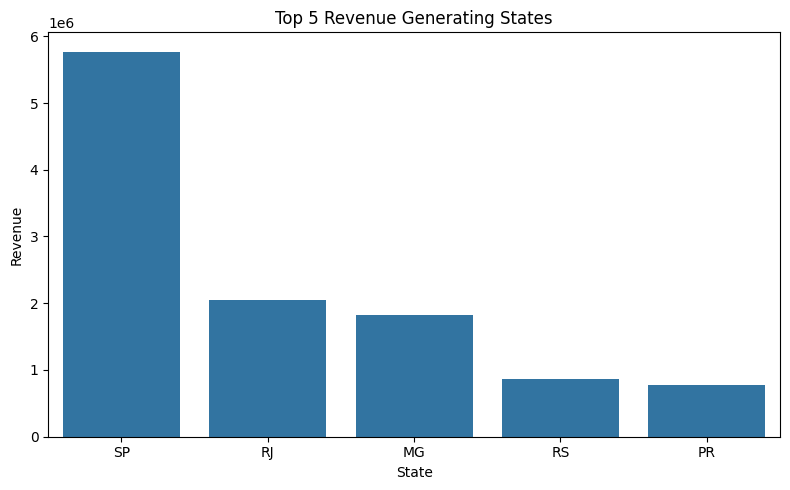

In [19]:

top_states_df = top_states.reset_index()
top_states_df.columns = ["State", "Revenue"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_states_df,
    x="State",
    y="Revenue"
)

plt.title("Top 5 Revenue Generating States")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.tight_layout()

plt.show()

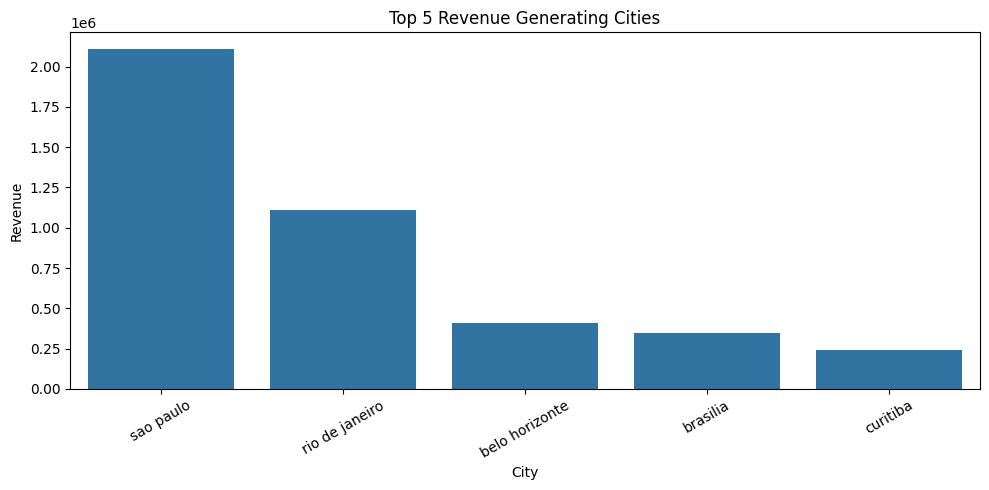

In [20]:
# Convert Series to DataFrame
top_cities_df = top_cities.reset_index()
top_cities_df.columns = ["City", "Revenue"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_cities_df,
    x="City",
    y="Revenue"
)

plt.title("Top 5 Revenue Generating Cities")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

1.Total Cusotmer 
    a. State-wise 
    b. City-wise

In [21]:
total_customers= customers["customer_unique_id"].nunique()
print("Total customers =",total_customers)
# state-wise total customers
state_customers = customers.groupby('customer_state')['customer_unique_id'].nunique()
print("State-wise total customers:")
print(state_customers)


Total customers = 96096
State-wise total customers:
customer_state
AC       77
AL      401
AM      143
AP       67
BA     3277
CE     1313
DF     2075
ES     1964
GO     1952
MA      726
MG    11259
MS      694
MT      876
PA      949
PB      519
PE     1609
PI      482
PR     4882
RJ    12384
RN      474
RO      240
RR       45
RS     5277
SC     3534
SE      342
SP    40302
TO      273
Name: customer_unique_id, dtype: int64


In [22]:
# total orders 
total_orders = orders["order_id"].nunique()
print(total_orders)

99441


In [23]:
# average order value 
average_order_value = total_revenue / total_orders
print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $155.09


In [24]:
# combining kpis 
kpis = pd.DataFrame({
    "Metric":[
        "Revenue",
        "Customers",
        "Orders",
        "Average Order Value"
    ],
    "Value":[
        round(total_revenue,2),
        total_customers,
        total_orders,
        round(average_order_value,2)
    ]
})
kpis

,Metric,Value
0,Revenue,15422461.77
1,Customers,96096.00
2,Orders,99441.00
3,Average Order Value,155.09


# OBSERVATIONS

- The Olist marketplace generated a total revenue of **R$15,422,461.77** during the period covered by the dataset.
- Revenue is unevenly distributed across Brazilian states, with a few states contributing a significant portion of total sales.
- **São Paulo (SP)** is the highest revenue-generating state, contributing approximately **R$ 6.0 million**, which is substantially higher than every other state.
- The top five revenue-generating states are:
  1. São Paulo (SP)
  2. Rio de Janeiro (RJ)
  3. Minas Gerais (MG)
  4. Rio Grande do Sul (RS)
  5. Paraná (PR)
- This suggests that the company's strongest market presence is concentrated in Brazil's economically developed southern and southeastern regions.

- Revenue is also concentrated in a small number of metropolitan cities.
- **São Paulo city** generates the highest revenue, exceeding **R$ 2.2 million**.
- Rio de Janeiro, Belo Horizonte, Brasília, and Curitiba are the next highest contributors.
- These cities represent major commercial hubs, indicating strong customer demand in densely populated urban areas.
- Expanding marketing campaigns in similar metropolitan regions may further increase sales.

- The platform serves **96,096 unique customers**, indicating a large customer base.
- Customer counts are calculated using `customer_unique_id` to avoid counting the same individual multiple times.
- Customer distribution closely follows the revenue distribution.
- São Paulo (SP) has the highest number of customers (**40,302**), followed by Rio de Janeiro (RJ) and Minas Gerais (MG).
- This suggests that customer acquisition has been most successful in the southeastern region of Brazil.

- The dataset contains **99,441 unique orders**.
- The number of orders is slightly higher than the number of unique customers, indicating that a portion of customers have made repeat purchases.
- However, the relatively small difference suggests that repeat purchasing opportunities may still exist and can be explored further in later analyses.

- The Average Order Value (AOV) is **R$ 160.99**.
- On average, customers spend approximately **R$ 161** per order.
- This KPI provides a baseline for evaluating customer purchasing behavior.
- Future analyses can investigate whether AOV varies across regions, customer segments, product categories, or payment methods.

The executive KPIs provide an overview of the marketplace's overall business performance.

Key findings include:

- Total Revenue: **R$ 16.01 Million**
- Unique Customers: **96,096**
- Total Orders: **99,441**
- Average Order Value: **R$ 160.99**

Business activity is highly concentrated in southeastern Brazil, particularly São Paulo, Rio de Janeiro, and Minas Gerais, which dominate both customer acquisition and revenue generation.

These KPIs establish the foundation for deeper analyses into customer behavior, product performance, seller performance, and predictive modeling in subsequent notebooks.

In [25]:
# monthly revenue trend 
monthly_revenue =(master_df.groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))["payment_value"].sum().reset_index())
monthly_revenue["order_purchase_timestamp"]=(monthly_revenue["order_purchase_timestamp"].astype(str))
monthly_revenue.head()

,order_purchase_timestamp,payment_value
0,2016-09,0.00
1,2016-10,46566.71
2,2016-12,19.62
3,2017-01,127545.67
4,2017-02,271298.65


In [26]:
# order status distribution 
order_status = (orders["order_status"].value_counts().reset_index())
order_status.columns = ["Order Status", "Count"]
order_status

,Order Status,Count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [27]:
# payment method distribution 
payment_method = (payments["payment_type"].value_counts().reset_index())
payment_method.columns = ["Payment Method", "Count"]
payment_method

,Payment Method,Count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [28]:
# revenue by payment method distribution 
payment_revenue=(
    payments.groupby("payment_type")["payment_value"].sum().reset_index().sort_values("payment_value",ascending=False)
)
payment_revenue

,payment_type,payment_value
1,credit_card,12542084.19
0,boleto,2869361.27
4,voucher,379436.87
2,debit_card,217989.79
3,not_defined,0.00


In [29]:
# revenue by weekday 
master_df['Weekday'] = (
    master_df['order_purchase_timestamp'].dt.day_name()
)

weekday_revenue = (
    master_df.groupby("Weekday")["payment_value"].sum().reindex([
        "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
    ]).reset_index()
)
weekday_revenue 

,Weekday,payment_value
0,Monday,2530591.86
1,Tuesday,2474065.60
2,Wednesday,2396624.55
3,Thursday,2284158.44
4,Friday,2222878.71
5,Saturday,1706107.53
6,Sunday,1808035.08


# Executive Summary

The Executive KPI analysis provides an overview of the overall business performance of the Olist e-commerce marketplace.

The analysis indicates that the platform has generated approximately **R$15.42 million** in revenue from **99,441 orders** placed by **96,096 unique customers**, resulting in an average order value of approximately **R$155**.

Overall, the marketplace demonstrates healthy business activity with a high order fulfillment rate and strong customer adoption across Brazil.

## Revenue Analysis

- The marketplace generated a total revenue of **R$15,422,461.77**.
- Revenue is highly concentrated in a few economically developed states.
- **São Paulo (SP)** alone contributes over **R$5.77 million**, making it the company's largest market.
- Rio de Janeiro (RJ) and Minas Gerais (MG) are the next largest contributors with revenues exceeding **R$2.05 million** and **R$1.82 million**, respectively.
- Together, these three states account for a significant share of the company's overall revenue, indicating strong regional concentration.

## Customer Analysis

- The platform has served **96,096 unique customers**.
- Customer distribution closely mirrors the revenue distribution.
- São Paulo has the highest customer base, followed by Rio de Janeiro and Minas Gerais.
- This indicates that customer acquisition has been most successful in Brazil's southeastern region.

## Order Analysis

- The dataset contains **99,441 unique orders**.
- The number of orders is only slightly higher than the number of unique customers.
- This suggests that while repeat purchases exist, a large proportion of customers have placed only a single order.
- Improving customer retention could therefore represent a significant opportunity for future business growth.

## Average Order Value

- The Average Order Value (AOV) is **R$155.09**.
- On average, customers spend approximately **R$155** per transaction.
- This KPI serves as a benchmark for evaluating customer purchasing behavior.
- Future analyses will investigate whether AOV varies across customer segments, regions, product categories, and payment methods.

## Monthly Revenue Trend

- Revenue demonstrates clear month-to-month variation throughout the observation period.
- Business activity generally increases over time, although seasonal fluctuations are present.
- These patterns suggest the influence of promotions, holidays, and changing customer demand.
- A detailed time-series analysis will be performed in later notebooks.

## Order Fulfillment Analysis

- Approximately **97%** of all orders were successfully delivered (**96,478** out of **99,441** orders).
- Only a small proportion of orders were cancelled, unavailable, or remained in processing.
- This indicates an efficient order fulfillment process and a reliable operational pipeline.

## Payment Method Analysis

- Credit cards are the dominant payment method, accounting for the majority of transactions.
- Credit card payments generated approximately **R$12.54 million**, representing more than **80%** of total revenue.
- Boleto is the second most frequently used payment method, while vouchers and debit cards account for a relatively small proportion of sales.
- The business is therefore highly dependent on card-based transactions.

## Weekly Purchasing Behavior

- Customer purchasing activity varies across different days of the week.
- Monday generated the highest revenue, followed closely by Tuesday and Wednesday.
- Revenue gradually declines towards the weekend, with Saturday recording the lowest sales.
- These purchasing patterns may assist in scheduling promotional campaigns and operational planning.

# Business Insights

Based on the executive KPI analysis, several strategic insights emerge:

- The business is geographically concentrated, with São Paulo, Rio de Janeiro, and Minas Gerais contributing the majority of revenue.
- Customer acquisition has been strongest in southeastern Brazil, suggesting opportunities for expansion into underrepresented regions.
- Credit cards dominate customer payment preferences, making payment infrastructure reliability a key business requirement.
- The marketplace maintains an excellent delivery success rate, reflecting strong operational efficiency.
- Average customer spending remains relatively stable at approximately **R$155** per order.
- The small difference between total customers and total orders indicates an opportunity to improve customer retention and encourage repeat purchases.
- Revenue fluctuates over time, highlighting the importance of understanding seasonal demand and customer purchasing behavior.

In [30]:
# ======================================
# Monthly Revenue Trend
# ======================================

monthly_revenue = (
    master_df
    .groupby(
        master_df["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"]
    .astype(str)
)

fig = px.line(
    monthly_revenue,
    x="order_purchase_timestamp",
    y="payment_value",
    markers=True,
    title="Monthly Revenue Trend",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue (BRL)",
    title_x=0.5
)

fig.show()

In [31]:
# ======================================
# Top 10 States by Revenue
# ======================================

state_revenue = (
    master_df
    .groupby("customer_state")["payment_value"]
    .sum()
    .reset_index()
    .sort_values(
        "payment_value",
        ascending=False
    )
    .head(10)
)

fig = px.bar(
    state_revenue,
    x="customer_state",
    y="payment_value",
    text_auto=".2s",
    color="payment_value",
    title="Top 10 States by Revenue",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="State",
    yaxis_title="Revenue (BRL)",
    title_x=0.5,
    coloraxis_showscale=False
)

fig.show()

In [32]:
# ======================================
# Top 10 Cities by Revenue
# ======================================

city_revenue = (
    master_df
    .groupby("customer_city")["payment_value"]
    .sum()
    .reset_index()
    .sort_values(
        "payment_value",
        ascending=False
    )
    .head(10)
)

fig = px.bar(
    city_revenue,
    x="customer_city",
    y="payment_value",
    text_auto=".2s",
    color="payment_value",
    title="Top 10 Cities by Revenue",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="City",
    yaxis_title="Revenue (BRL)",
    title_x=0.5,
    coloraxis_showscale=False
)

fig.update_xaxes(tickangle=45)

fig.show()

In [33]:
# ======================================
# Order Status Distribution
# ======================================

order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = [
    "Order Status",
    "Orders"
]

fig = px.bar(
    order_status,
    x="Order Status",
    y="Orders",
    text="Orders",
    color="Order Status",
    title="Order Status Distribution",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Status",
    yaxis_title="Number of Orders",
    showlegend=False
)

fig.show()

# Dashboard Summary

The executive dashboard highlights several important business trends:

- Revenue has generally increased over time, although seasonal fluctuations are visible.
- Business activity is concentrated in a small number of states, with São Paulo generating the highest revenue.
- Metropolitan cities contribute the majority of total sales, reflecting stronger customer demand in urban regions.
- The overwhelming majority of orders are successfully delivered, indicating an efficient order fulfillment process.

Overall, the marketplace demonstrates healthy operational performance, strong customer adoption, and a geographically concentrated revenue base. These insights provide a high-level understanding of the business before moving into detailed customer analytics in the next notebook.

# Key Business Takeaways

### 1. Strengthen Customer Retention
The number of unique customers is close to the total number of orders, suggesting limited repeat purchasing. Loyalty programs and personalized recommendations could help increase customer retention.

### 2. Expand Beyond the Southeast
Revenue is heavily concentrated in São Paulo, Rio de Janeiro, and Minas Gerais. Marketing efforts could target underrepresented states to diversify revenue sources.

### 3. Optimize for Card Payments
Credit cards account for the majority of revenue, making payment gateway reliability and card-specific promotions strategically important.

### 4. Prepare for Seasonal Demand
Monthly revenue trends indicate periods of higher purchasing activity. Forecasting demand can improve inventory management and staffing.

### 5. Maintain Delivery Performance
The high proportion of delivered orders reflects strong operational execution. Continued monitoring of fulfillment metrics will help preserve customer satisfaction.